# Six-parameter PFF data with detector augmentation

This notebook retains the final six-parameter PFF spectrum:

\[
s(E)=a_1e^{-a_2E}
+a_3\exp\left[
-\frac{(E-a_4)^2}{a_5E+a_6/E}
\right].
\]

The ideal energy spectrum is **not** used directly as the neural-network input.
It is first transformed by the detector response matrix (DRM):

\[
\text{detector response}=\text{spectrum}\times\text{DRM}.
\]

Because the DRM mixes and weights energy bins differently, the resulting
200-channel detector signal does not have to look like a simple downward
exponential from left to right.

This version also adds detector behavior used by `data_utils.py` while retaining
the six-parameter spectrum family:

- balanced bump/no-bump spectra;
- configurable shot-noise variance;
- additive read/dark noise;
- optional signal-proportional noise;
- optional exact Poisson sampling;
- saturation/flat-top augmentation;
- L1 normalization and training-only z-score fitting;
- `(4, 48, 1)` fine input plus an independent `(8,)` coarse input.

Real-image loading and Gaussian correction of already-saturated `.tif` files
remain inference/preprocessing operations and are intentionally not applied to
synthetic spectra.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

## Configuration

In [2]:
# Path to the same 200 x 200 DRM CSV used by the original notebook.
DRM_CSV_PATH = Path("res/drm/200x200.csv")

NUM_ENERGY_BINS = 50
NUM_SAMPLES = 100_000
VAL_SAMPLES = 5_000
BATCH_GENERATION_SIZE = 5_000
SEED = 42

# ------------------------------------------------------------------
# Six-parameter spectrum distribution
# ------------------------------------------------------------------

# Match data_utils by explicitly including both bump and no-bump examples.
BUMP_FRACTION = 0.50
BUMP_AMPLITUDE_MIN = 5.0

# ------------------------------------------------------------------
# Detector noise model
# ------------------------------------------------------------------

# Options:
#   "data_utils"   -> Gaussian shot-noise approximation plus read/multiplicative noise
#   "exact_poisson"-> exact Poisson draw (assuming DRM values represent expected counts)
#   "none"         -> clean DRM responses
NOISE_MODEL = "data_utils"

# data_utils-style defaults:
#
# variance_i =
#     NOISE_GAIN * response_i
#     + (READ_FRAC * sample_peak)^2
#     + (MULT_FRAC * response_i)^2
#
# NOISE_GAIN=1 and READ_FRAC=MULT_FRAC=0 reproduces the usual
# Gaussian approximation sigma=sqrt(response).
NOISE_GAIN = 5.0
READ_FRAC = 0.10
MULT_FRAC = 0.0

# ------------------------------------------------------------------
# Synthetic saturation augmentation
# ------------------------------------------------------------------

SAT_FRACTION = 0.30
SAT_CEIL_LOW = 0.55
SAT_CEIL_HIGH = 0.95

# Save all model-ready arrays at the end.
OUTPUT_PATH = Path(
    f"six_param_hybrid_detector_augmented_n{NUM_ENERGY_BINS}.npz"
)

assert 200 % NUM_ENERGY_BINS == 0
assert 0 < VAL_SAMPLES < NUM_SAMPLES
assert 0.0 <= BUMP_FRACTION <= 1.0
assert 0.0 <= SAT_FRACTION <= 1.0
assert 0.0 < SAT_CEIL_LOW <= SAT_CEIL_HIGH <= 1.0
assert NOISE_MODEL in {"data_utils", "exact_poisson", "none"}


## Load and bin the detector response matrix

In [3]:
# The original CSV is assumed to have:
#   rows    = 200 true-energy bins
#   columns = 200 detector channels
drm_200 = np.loadtxt(DRM_CSV_PATH, delimiter=",").astype(np.float32)

if drm_200.shape != (200, 200):
    raise ValueError(
        f"Expected a (200, 200) DRM, but received {drm_200.shape}."
    )

bins_per_group = 200 // NUM_ENERGY_BINS

# Average consecutive true-energy rows:
#   (200 energy bins, 200 detector channels)
#       -> (NUM_ENERGY_BINS, 200 detector channels)
drm_energy_detector = drm_200.reshape(
    NUM_ENERGY_BINS,
    bins_per_group,
    200,
).mean(axis=1).astype(np.float32)

# Match data_utils.mev_bin_centers:
# for 50 bins across 0--50 MeV, centers are 0.5, 1.5, ..., 49.5 MeV.
bin_width_mev = 50.0 / NUM_ENERGY_BINS
energy_bins = (
    (np.arange(NUM_ENERGY_BINS, dtype=np.float32) + 0.5)
    * bin_width_mev
)

print("Original DRM:", drm_200.shape)
print("Binned DRM:", drm_energy_detector.shape)
print("Energy bins:", energy_bins.shape)
print(
    "Energy range:",
    float(energy_bins[0]),
    "to",
    float(energy_bins[-1]),
    "MeV",
)


Original DRM: (200, 200)
Binned DRM: (50, 200)
Energy bins: (50,)
Energy range: 0.5 to 49.5 MeV


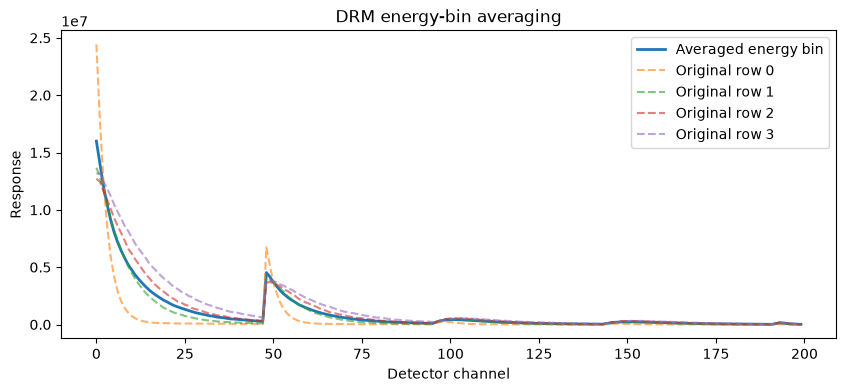

In [4]:
# Compare the first averaged response with the four original rows.
plt.figure(figsize=(10, 4))
plt.plot(drm_energy_detector[0], label="Averaged energy bin", linewidth=2)
for row in range(bins_per_group):
    plt.plot(drm_200[row], "--", alpha=0.6, label=f"Original row {row}")
plt.xlabel("Detector channel")
plt.ylabel("Response")
plt.title("DRM energy-bin averaging")
plt.legend()
plt.show()

## Six-parameter PFF equation and bounded parameter sampling

In [5]:
def original_pff_func(
    energy: np.ndarray,
    params: np.ndarray,
) -> np.ndarray:
    """
    Evaluate one or many six-parameter PFF spectra.

    energy:
        shape (M,)

    params:
        shape (6,) or (N, 6)

    returns:
        shape (M,) or (N, M)
    """
    energy = np.asarray(energy, dtype=np.float64)
    params = np.asarray(params, dtype=np.float64)

    single_sample = params.ndim == 1
    if single_sample:
        params = params[np.newaxis, :]

    if params.ndim != 2 or params.shape[1] != 6:
        raise ValueError("params must have shape (6,) or (N, 6).")

    E = energy[np.newaxis, :]
    a1, a2, a3, a4, a5, a6 = (
        params[:, j, np.newaxis] for j in range(6)
    )

    denominator = a5 * E + a6 / E
    denominator = np.maximum(denominator, 1e-12)

    spectra = (
        a1 * np.exp(-a2 * E)
        + a3 * np.exp(-((E - a4) ** 2) / denominator)
    )

    return spectra[0] if single_sample else spectra


# Columns are [mean, standard deviation, lower bound, upper bound].
# These preserve the final six-parameter ranges from the original notebook.
PFF6_PARAM_RANGES = np.array(
    [
        [150.0, 100.0, 50.0, 250.0],   # a1
        [0.3,     1.0,  0.01,   2.0],  # a2
        [20.0,   10.0,  0.0,   50.0],  # a3
        [20.0,   25.0,  1.0,   49.0],  # a4
        [0.5,     1.0,  1e-6,  10.0],  # a5
        [100.0, 500.0,  1e-6, 1e4],    # a6
    ],
    dtype=np.float64,
)


def sample_bounded_normal_parameters(
    n_samples: int,
    rng: np.random.Generator,
    bump_fraction: float = 0.5,
    bump_amplitude_min: float = 5.0,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Sample bounded six-parameter sets.

    A random `bump_fraction` of samples retain a visible bump with
    a3 >= bump_amplitude_min. The remainder have a3 = 0 while still using
    the same six-parameter equation.
    """
    means = PFF6_PARAM_RANGES[:, 0]
    stds = PFF6_PARAM_RANGES[:, 1]
    lower = PFF6_PARAM_RANGES[:, 2]
    upper = PFF6_PARAM_RANGES[:, 3]

    params = rng.normal(means, stds, size=(n_samples, 6))
    invalid = (params < lower) | (params > upper)

    while invalid.any():
        redraw = rng.normal(means, stds, size=(n_samples, 6))
        params = np.where(invalid, redraw, params)
        invalid = (params < lower) | (params > upper)

    has_bump = rng.random(n_samples) < bump_fraction

    # No-bump examples remain valid members of the six-parameter family.
    params[~has_bump, 2] = 0.0

    # Ensure bump-present examples have a visible bump, matching data_utils.
    invalid_bump = has_bump & (params[:, 2] < bump_amplitude_min)
    while invalid_bump.any():
        params[invalid_bump, 2] = rng.normal(
            PFF6_PARAM_RANGES[2, 0],
            PFF6_PARAM_RANGES[2, 1],
            size=invalid_bump.sum(),
        )
        invalid_bump = has_bump & (
            (params[:, 2] < bump_amplitude_min)
            | (params[:, 2] > PFF6_PARAM_RANGES[2, 3])
        )

    return params, has_bump


## Generate six-parameter spectra and detector-augmented responses

`responses_clean` is the ideal DRM output. Noise and saturation are added only
to the neural-network input; the target remains the clean six-parameter
spectrum.


In [6]:
def add_detector_noise(
    responses: np.ndarray,
    rng: np.random.Generator,
    noise_model: str = "data_utils",
    noise_gain: float = 5.0,
    read_frac: float = 0.10,
    mult_frac: float = 0.0,
) -> np.ndarray:
    """
    Add detector noise while preserving non-negative responses.

    data_utils:
        Gaussian approximation with
        variance = gain*signal + read_floor^2 + multiplicative_term^2

    exact_poisson:
        Uses Poisson(signal / gain) * gain so the output variance is
        approximately gain*signal, then adds read/multiplicative Gaussian noise.

    none:
        Returns a copy of the clean DRM response.
    """
    responses = np.maximum(
        np.asarray(responses, dtype=np.float64),
        0.0,
    )

    if noise_model == "none":
        return responses.astype(np.float32)

    peak = responses.max(axis=1, keepdims=True)
    extra_variance = (
        (read_frac * peak) ** 2
        + (mult_frac * responses) ** 2
    )

    if noise_model == "data_utils":
        variance = (
            noise_gain * responses
            + extra_variance
        )
        sigma = np.sqrt(np.maximum(variance, 1e-12))
        noisy = (
            responses
            + rng.standard_normal(responses.shape) * sigma
        )

    elif noise_model == "exact_poisson":
        if noise_gain <= 0.0:
            raise ValueError(
                "noise_gain must be positive for exact_poisson."
            )

        # This assumes the clean response is proportional to expected counts.
        noisy = (
            rng.poisson(responses / noise_gain)
            * noise_gain
        ).astype(np.float64)

        if np.any(extra_variance > 0):
            noisy += (
                rng.standard_normal(responses.shape)
                * np.sqrt(np.maximum(extra_variance, 1e-12))
            )

    else:
        raise ValueError(
            "noise_model must be 'data_utils', 'exact_poisson', or 'none'."
        )

    return np.clip(noisy, 0.0, None).astype(np.float32)


def apply_saturation(
    responses: np.ndarray,
    rng: np.random.Generator,
    sat_fraction: float = 0.30,
    ceil_low: float = 0.55,
    ceil_high: float = 0.95,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Flat-top a random subset of synthetic detector responses.

    Each selected response receives a ceiling between `ceil_low` and
    `ceil_high` times its own peak. This teaches the network about the shape
    created by detector/ADC saturation.
    """
    responses = np.asarray(responses, dtype=np.float32)

    if sat_fraction <= 0.0 or responses.shape[0] == 0:
        return (
            responses.copy(),
            np.zeros(responses.shape[0], dtype=bool),
        )

    selected = rng.random(responses.shape[0]) < sat_fraction
    peak = responses.max(axis=1, keepdims=True)
    fraction = rng.uniform(
        ceil_low,
        ceil_high,
        size=(responses.shape[0], 1),
    )

    ceiling = np.where(
        selected[:, np.newaxis],
        fraction * peak,
        np.inf,
    )

    saturated = np.minimum(responses, ceiling)
    return saturated.astype(np.float32), selected


def generate_six_param_dataset(
    drm_energy_detector: np.ndarray,
    energy_bins: np.ndarray,
    n_samples: int,
    rng: np.random.Generator,
    batch_size: int = 5_000,
    bump_fraction: float = 0.5,
    bump_amplitude_min: float = 5.0,
    noise_model: str = "data_utils",
    noise_gain: float = 5.0,
    read_frac: float = 0.10,
    mult_frac: float = 0.0,
    sat_fraction: float = 0.30,
    sat_ceil_low: float = 0.55,
    sat_ceil_high: float = 0.95,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """
    Generate detector-input/spectrum-target pairs.

    Returns
    -------
    detector_responses:
        (n_samples, 200), noisy and possibly saturated, float32

    spectra:
        (n_samples, n_energy_bins), clean six-parameter spectra, float32

    parameters:
        (n_samples, 6), float32

    has_bump:
        (n_samples,), bool

    was_saturated:
        (n_samples,), bool
    """
    n_energy_bins, n_detector_channels = drm_energy_detector.shape

    detector_responses = np.empty(
        (n_samples, n_detector_channels),
        dtype=np.float32,
    )
    spectra = np.empty(
        (n_samples, n_energy_bins),
        dtype=np.float32,
    )
    parameters = np.empty(
        (n_samples, 6),
        dtype=np.float32,
    )
    has_bump_all = np.empty(n_samples, dtype=bool)
    was_saturated_all = np.empty(n_samples, dtype=bool)

    for start in range(0, n_samples, batch_size):
        stop = min(start + batch_size, n_samples)
        current_n = stop - start

        params_batch, has_bump_batch = (
            sample_bounded_normal_parameters(
                current_n,
                rng,
                bump_fraction=bump_fraction,
                bump_amplitude_min=bump_amplitude_min,
            )
        )

        spectra_batch = original_pff_func(
            energy_bins,
            params_batch,
        )

        # The DRM is what turns an ideal exponential-plus-bump spectrum into
        # the detector's generally non-exponential 200-channel response.
        responses_clean = (
            spectra_batch @ drm_energy_detector
        )

        responses_noisy = add_detector_noise(
            responses_clean,
            rng,
            noise_model=noise_model,
            noise_gain=noise_gain,
            read_frac=read_frac,
            mult_frac=mult_frac,
        )

        responses_augmented, saturated_batch = apply_saturation(
            responses_noisy,
            rng,
            sat_fraction=sat_fraction,
            ceil_low=sat_ceil_low,
            ceil_high=sat_ceil_high,
        )

        detector_responses[start:stop] = responses_augmented
        spectra[start:stop] = spectra_batch.astype(np.float32)
        parameters[start:stop] = params_batch.astype(np.float32)
        has_bump_all[start:stop] = has_bump_batch
        was_saturated_all[start:stop] = saturated_batch

    return (
        detector_responses,
        spectra,
        parameters,
        has_bump_all,
        was_saturated_all,
    )


rng = np.random.default_rng(SEED)

(
    X_raw,
    y_raw,
    pff6_parameters,
    has_bump,
    was_saturated,
) = generate_six_param_dataset(
    drm_energy_detector=drm_energy_detector,
    energy_bins=energy_bins,
    n_samples=NUM_SAMPLES,
    rng=rng,
    batch_size=BATCH_GENERATION_SIZE,
    bump_fraction=BUMP_FRACTION,
    bump_amplitude_min=BUMP_AMPLITUDE_MIN,
    noise_model=NOISE_MODEL,
    noise_gain=NOISE_GAIN,
    read_frac=READ_FRAC,
    mult_frac=MULT_FRAC,
    sat_fraction=SAT_FRACTION,
    sat_ceil_low=SAT_CEIL_LOW,
    sat_ceil_high=SAT_CEIL_HIGH,
)

print("Augmented detector responses:", X_raw.shape)
print("Clean spectrum targets:", y_raw.shape)
print("Six-parameter values:", pff6_parameters.shape)
print("Actual bump fraction:", has_bump.mean())
print("Actual saturated fraction:", was_saturated.mean())


Augmented detector responses: (100000, 200)
Clean spectrum targets: (100000, 50)
Six-parameter values: (100000, 6)
Actual bump fraction: 0.50137
Actual saturated fraction: 0.30103


## Shuffle, normalize, and split for the hybrid spectrum model

In [7]:
def l1_normalize_rows(array: np.ndarray) -> np.ndarray:
    row_sums = array.sum(axis=1, keepdims=True)
    return (
        array / np.maximum(row_sums, 1e-12)
    ).astype(np.float32)


# Shuffle all related arrays together before the train/validation split.
permutation = rng.permutation(NUM_SAMPLES)
X_raw = X_raw[permutation]
y_raw = y_raw[permutation]
pff6_parameters = pff6_parameters[permutation]
has_bump = has_bump[permutation]
was_saturated = was_saturated[permutation]

# The hybrid model's softmax output represents a distribution, so both
# detector responses and spectrum targets are L1-normalized.
X_l1 = l1_normalize_rows(X_raw)
y = l1_normalize_rows(y_raw)

train_stop = NUM_SAMPLES - VAL_SAMPLES

# Fit z-score statistics using training data only to avoid validation leakage.
norm_mean = X_l1[:train_stop].mean(axis=0).astype(np.float32)
norm_std = np.maximum(
    X_l1[:train_stop].std(axis=0),
    1e-8,
).astype(np.float32)

X_normalized = (
    (X_l1 - norm_mean) / norm_std
).astype(np.float32)

print("Normalized detector data:", X_normalized.shape)
print("Target row sums:", y[:3].sum(axis=1))
print(
    "Training bump/saturation fractions:",
    has_bump[:train_stop].mean(),
    was_saturated[:train_stop].mean(),
)
print(
    "Validation bump/saturation fractions:",
    has_bump[train_stop:].mean(),
    was_saturated[train_stop:].mean(),
)


Normalized detector data: (100000, 200)
Target row sums: [1.         0.99999994 1.        ]
Training bump/saturation fractions: 0.5010526315789474 0.3010842105263158
Validation bump/saturation fractions: 0.5074 0.3


## Split the 200 measurements into `(4, 48, 1)` and `(8,)` branches

In [8]:
def split_detector_input(
    X: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Split each 200-channel detector response without repeating any values.

    First 192 channels:
        (N, 192) -> (N, 4, 48, 1)

    Final eight channels:
        (N, 8)
    """
    if X.ndim != 2 or X.shape[1] != 200:
        raise ValueError(
            f"Expected X with shape (N, 200), received {X.shape}."
        )

    fine_image = X[:, :192].reshape(
        -1,
        4,
        48,
        1,
    ).astype(np.float32)

    coarse_pixels = X[:, 192:200].astype(np.float32)

    return fine_image, coarse_pixels


X_fine, X_coarse = split_detector_input(X_normalized)

X_train_fine = X_fine[:train_stop]
X_train_coarse = X_coarse[:train_stop]
y_train = y[:train_stop]

X_val_fine = X_fine[train_stop:]
X_val_coarse = X_coarse[train_stop:]
y_val = y[train_stop:]

print("X_train_fine:", X_train_fine.shape)
print("X_train_coarse:", X_train_coarse.shape)
print("y_train:", y_train.shape)
print()
print("X_val_fine:", X_val_fine.shape)
print("X_val_coarse:", X_val_coarse.shape)
print("y_val:", y_val.shape)

X_train_fine: (95000, 4, 48, 1)
X_train_coarse: (95000, 8)
y_train: (95000, 50)

X_val_fine: (5000, 4, 48, 1)
X_val_coarse: (5000, 8)
y_val: (5000, 50)


## Inspect the spectrum, clean DRM response, and augmented detector signal

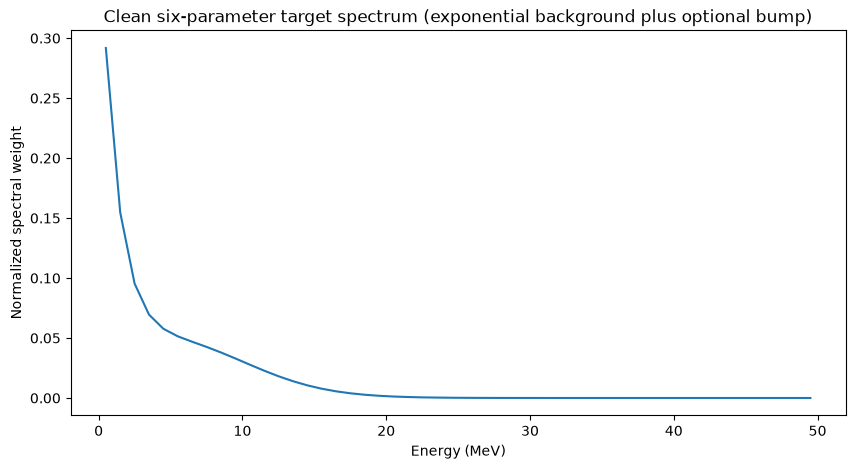

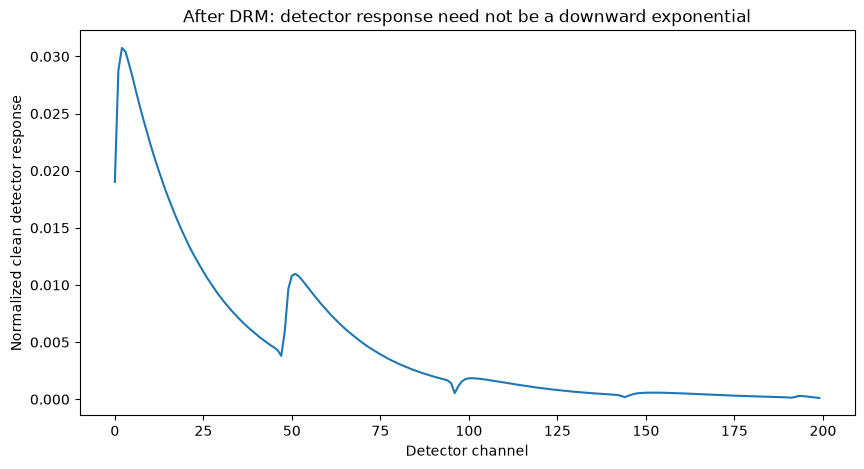

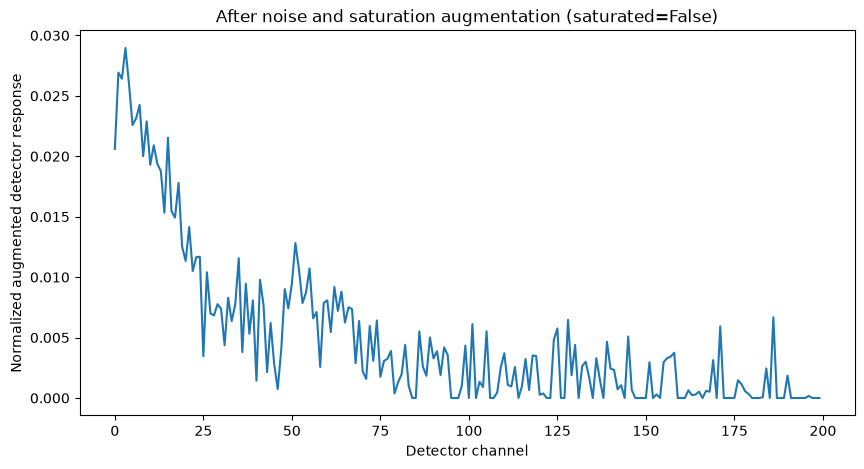

In [9]:
# Compare the stages for one generated example.
example_index = 0

clean_response_example = (
    y_raw[example_index:example_index + 1]
    @ drm_energy_detector
)
clean_response_example_l1 = l1_normalize_rows(
    clean_response_example
)[0]

plt.figure(figsize=(10, 5))
plt.plot(
    energy_bins,
    y[example_index],
)
plt.xlabel("Energy (MeV)")
plt.ylabel("Normalized spectral weight")
plt.title(
    "Clean six-parameter target spectrum "
    "(exponential background plus optional bump)"
)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(clean_response_example_l1)
plt.xlabel("Detector channel")
plt.ylabel("Normalized clean detector response")
plt.title(
    "After DRM: detector response need not be a downward exponential"
)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(X_l1[example_index])
plt.xlabel("Detector channel")
plt.ylabel("Normalized augmented detector response")
plt.title(
    f"After noise and saturation augmentation "
    f"(saturated={bool(was_saturated[example_index])})"
)
plt.show()


## Save model-ready arrays and detector-augmentation metadata

In [10]:
np.savez(
    OUTPUT_PATH,
    X_train_fine=X_train_fine,
    X_train_coarse=X_train_coarse,
    y_train=y_train,
    X_val_fine=X_val_fine,
    X_val_coarse=X_val_coarse,
    y_val=y_val,
    norm_mean=norm_mean,
    norm_std=norm_std,
    energy_bins=energy_bins,
    pff6_parameters=pff6_parameters,
    has_bump=has_bump,
    was_saturated=was_saturated,
    noise_model=np.array(NOISE_MODEL),
    noise_gain=np.array(NOISE_GAIN, dtype=np.float32),
    read_frac=np.array(READ_FRAC, dtype=np.float32),
    mult_frac=np.array(MULT_FRAC, dtype=np.float32),
    sat_fraction=np.array(SAT_FRACTION, dtype=np.float32),
    sat_ceil_low=np.array(SAT_CEIL_LOW, dtype=np.float32),
    sat_ceil_high=np.array(SAT_CEIL_HIGH, dtype=np.float32),
)

print(f"Saved model-ready data to: {OUTPUT_PATH.resolve()}")


Saved model-ready data to: C:\Users\aayan\OneDrive\Documents\GitHub\SAS-Analysis-Laser\six_param_hybrid_detector_augmented_n50.npz


## Fit the existing hybrid model

In [11]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# Import only the function needed instead of using import *
from train_cnn_hybrid import build_model


# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

# Use the same bin count that generated y_train.
# Do not redefine NUM_ENERGY_BINS here.
assert y_train.shape[1] == NUM_ENERGY_BINS

MAX_EPOCHS = 200
BATCH_SIZE = 256

BEST_MODEL_PATH = (
    f"best_model_6param_hybrid_n{NUM_ENERGY_BINS}.keras"
)

HISTORY_CSV_PATH = (
    f"training_history_6param_hybrid_n{NUM_ENERGY_BINS}.csv"
)

HISTORY_JSON_PATH = (
    f"training_history_6param_hybrid_n{NUM_ENERGY_BINS}.json"
)

SUMMARY_PATH = (
    f"training_summary_6param_hybrid_n{NUM_ENERGY_BINS}.json"
)


# ------------------------------------------------------------------
# Build and compile model
# ------------------------------------------------------------------

model = build_model(NUM_ENERGY_BINS)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3,
        clipnorm=1.0,
    ),
    loss="mse",
    metrics=["mae"],
)


# ------------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------------

callbacks = [

    # Save the model only when validation loss improves.
    # At the end, this file contains the model from the best epoch.
    tf.keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),

    # Stop training when validation loss has not improved for 30 epochs.
    # Also put the best weights back into the in-memory model.
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=30,
        restore_best_weights=True,
        verbose=1,
    ),

    # Reduce the learning rate when validation improvement stalls.
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=10,
        min_lr=1e-5,
        verbose=1,
    ),

    # Write the loss and metrics to a CSV file after every epoch.
    tf.keras.callbacks.CSVLogger(
        HISTORY_CSV_PATH,
    ),
]


# ------------------------------------------------------------------
# Train
# ------------------------------------------------------------------

history = model.fit(
    {
        "fine_image": X_train_fine,
        "coarse_pixels": X_train_coarse,
    },
    y_train,

    validation_data=(
        {
            "fine_image": X_val_fine,
            "coarse_pixels": X_val_coarse,
        },
        y_val,
    ),

    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)


# ------------------------------------------------------------------
# Find the best epoch
# ------------------------------------------------------------------

best_epoch_index = int(
    np.argmin(history.history["val_loss"])
)

# Add one because Python indexes epochs starting at zero.
best_epoch = best_epoch_index + 1

best_val_loss = float(
    history.history["val_loss"][best_epoch_index]
)

best_val_mae = float(
    history.history["val_mae"][best_epoch_index]
)

best_train_loss = float(
    history.history["loss"][best_epoch_index]
)

best_train_mae = float(
    history.history["mae"][best_epoch_index]
)


# ------------------------------------------------------------------
# Save training history
# ------------------------------------------------------------------

# Save every epoch's metrics as JSON.
with open(HISTORY_JSON_PATH, "w") as file:
    json.dump(
        history.history,
        file,
        indent=2,
    )

# This is optional because CSVLogger already creates a CSV,
# but it ensures the completed history is also stored.
pd.DataFrame(history.history).to_csv(
    HISTORY_CSV_PATH,
    index_label="epoch_index",
)


# ------------------------------------------------------------------
# Save a summary of the best epoch
# ------------------------------------------------------------------

training_summary = {
    "num_energy_bins": NUM_ENERGY_BINS,
    "epochs_completed": len(history.history["loss"]),
    "best_epoch": best_epoch,
    "best_train_loss": best_train_loss,
    "best_validation_loss": best_val_loss,
    "best_train_mae": best_train_mae,
    "best_validation_mae": best_val_mae,
    "best_model_path": BEST_MODEL_PATH,
}

with open(SUMMARY_PATH, "w") as file:
    json.dump(
        training_summary,
        file,
        indent=2,
    )


print("\nTraining complete")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.8f}")
print(f"Best validation MAE: {best_val_mae:.8f}")
print(f"Best model saved to: {BEST_MODEL_PATH}")
print(f"Training history saved to: {HISTORY_CSV_PATH}")
print(f"Training summary saved to: {SUMMARY_PATH}")

TensorFlow: 2.21.0
GPUs: []
Epoch 1/200
371/372 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 6.5375e-04 - mae: 0.0106
Epoch 1: val_loss improved from None to 0.00051, saving model to best_model_6param_hybrid_n50.keras

Epoch 1: finished saving model to best_model_6param_hybrid_n50.keras
372/372 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - loss: 6.5365e-04 - mae: 0.0106 - val_loss: 5.0956e-04 - val_mae: 0.0100 - learning_rate: 0.0010
Epoch 2/200
371/372 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 2.2770e-04 - mae: 0.0067
Epoch 2: val_loss improved from 0.00051 to 0.00023, saving model to best_model_6param_hybrid_n50.keras

Epoch 2: finished saving model to best_model_6param_hybrid_n50.keras
372/372 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - loss: 2.2771e-04 - mae: 0.0067 - val_loss: 2.3176e-04 - val_mae: 0.0066 - learning_rate: 0.0010
Epoch 3/200
371/372 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 2.1688e-04 - mae: 0.0063
Epoch 3: val_loss improved from 0.00023 to 0.00022, saving model to best_model_6param_

## Shapes and behavior produced

For `NUM_SAMPLES = 100000`, `VAL_SAMPLES = 5000`, and
`NUM_ENERGY_BINS = 50`:

| Array | Shape |
|---|---:|
| `X_train_fine` | `(95000, 4, 48, 1)` |
| `X_train_coarse` | `(95000, 8)` |
| `y_train` | `(95000, 50)` |
| `X_val_fine` | `(5000, 4, 48, 1)` |
| `X_val_coarse` | `(5000, 8)` |
| `y_val` | `(5000, 50)` |

The six-parameter equation still generates every target spectrum. The DRM,
noise model, and saturation augmentation modify only the simulated detector
input. The final eight detector measurements remain independent and are never
repeated into a fake fifth image row.

Set:

```python
NOISE_MODEL = "data_utils"
```

to match the uploaded `data_utils` detector-noise model, or:

```python
NOISE_MODEL = "exact_poisson"
```

to use exact Poisson draws when the DRM output can reasonably be interpreted as
expected detector counts.
